In [14]:
%load_ext autoreload
%autoreload 2
 
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')

from runtime.v4.semantics.load_semantics import load_semantics, load_idiom_rules
from runtime.v4.semantics.semantic_models import * 
from runtime.v4.analyst_agent.catalog import Catalog
from runtime.v4.analyst_agent.smart_data import SmartData
from runtime.v4.analyst_agent.smart_data_tools  import SmartDataTools
from runtime.v4.analyst_agent.analyst_models  import *
from runtime.v4.analyst_agent.analyst_prompts import system_prompt_template3 as agent_system_prompt


import  os  
from datetime import datetime 
from langchain_core.tools import StructuredTool, Tool


import duckdb
from typing import Any, Dict, List, Iterable, Union, Optional 
import yaml
import pprint
import pandas as pd, numpy as np
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
 
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
from langchain_core.runnables import RunnableLambda
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables import Runnable
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
 
 
from get_llm_model import azure_llm_if

class Task(BaseModel):
    tool: Literal[
        "analyst_agent",
        "explanation_rag",
        "general_knowledge_agent",
        "project_structure_agent",
        "information_request",
        "derive_from_context"
    ] = Field(
        description="Which agent/tool must execute this task."
    )

    instruction: str = Field(
        description=(
            "Exact instruction string to pass verbatim to the selected tool. "
            "Must be a complete, unambiguous request phrased as if directly "
            "addressing the tool."
        )
    )


class Plan(BaseModel):
    
    agent: Literal["planner"] = Field(
        description="Fixed identifier for the planner agent."
    )

    user_intent: str = Field(
        description="One-sentence clarified user intent."
    )

    tasks: List[Task] = Field(
        description="Ordered list of tool invocations required to satisfy the intent."
    )



In [4]:
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')


from get_llm_model import azure_llm_if

llm = azure_llm_if

from experiment2 import *  

imported


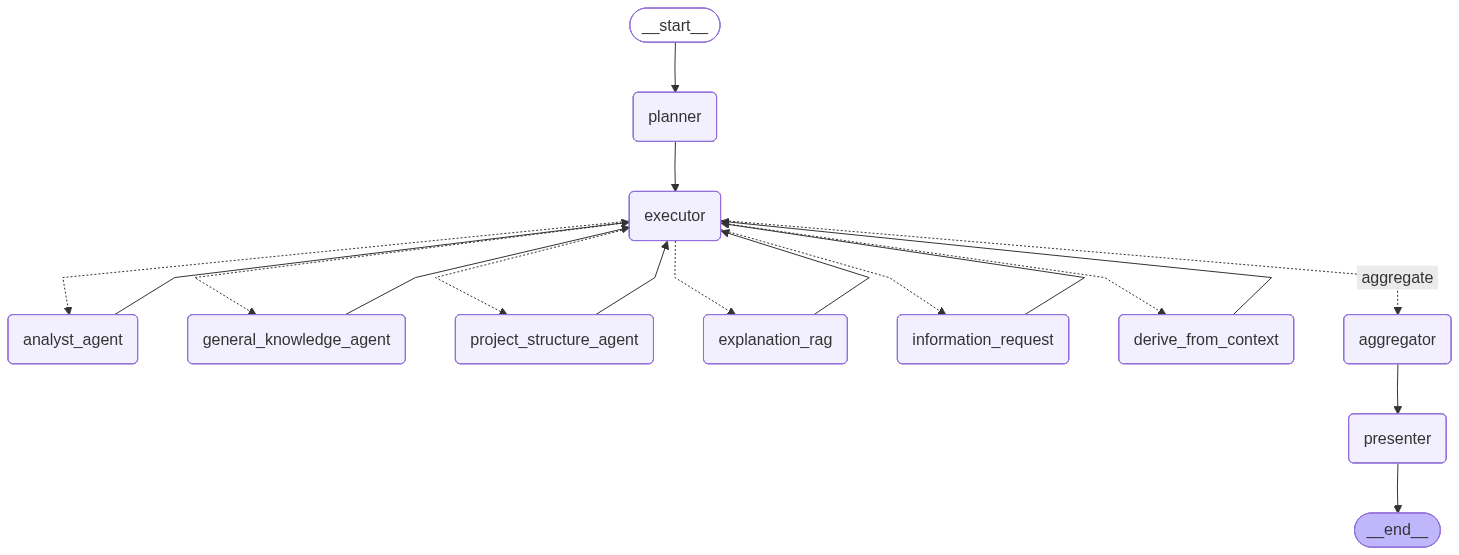

In [5]:



graph = StateGraph(ExecutorState)

graph.add_node("planner", planner_node)
graph.add_node("executor", executor_node)

graph.add_node("analyst_agent", analyst_node)
graph.add_node("general_knowledge_agent", general_knowledge_node)
graph.add_node("project_structure_agent", project_structure_node)
graph.add_node("explanation_rag", explanation_rag_node)
graph.add_node("information_request", information_request_node)
graph.add_node("derive_from_context", derive_from_context_node)

graph.add_node("aggregator", aggregator_node)
graph.add_node("presenter", presenter_node)

graph.set_entry_point("planner")

graph.add_edge("planner", "executor")

graph.add_conditional_edges(
    "executor",
    route_next_task,
    {
        "analyst_agent": "analyst_agent",
        "general_knowledge_agent": "general_knowledge_agent",
        "project_structure_agent": "project_structure_agent",
        "explanation_rag": "explanation_rag",
        "information_request": "information_request",
        "derive_from_context": "derive_from_context",
        "aggregate": "aggregator",
    },
)

for node_name in [
    "analyst_agent",
    "general_knowledge_agent",
    "project_structure_agent",
    "explanation_rag",
    "information_request",
    "derive_from_context",
]:
    graph.add_edge(node_name, "executor")

graph.add_edge("aggregator", "presenter")
graph.add_edge("presenter", END)

executor_app = graph.compile()

executor_app

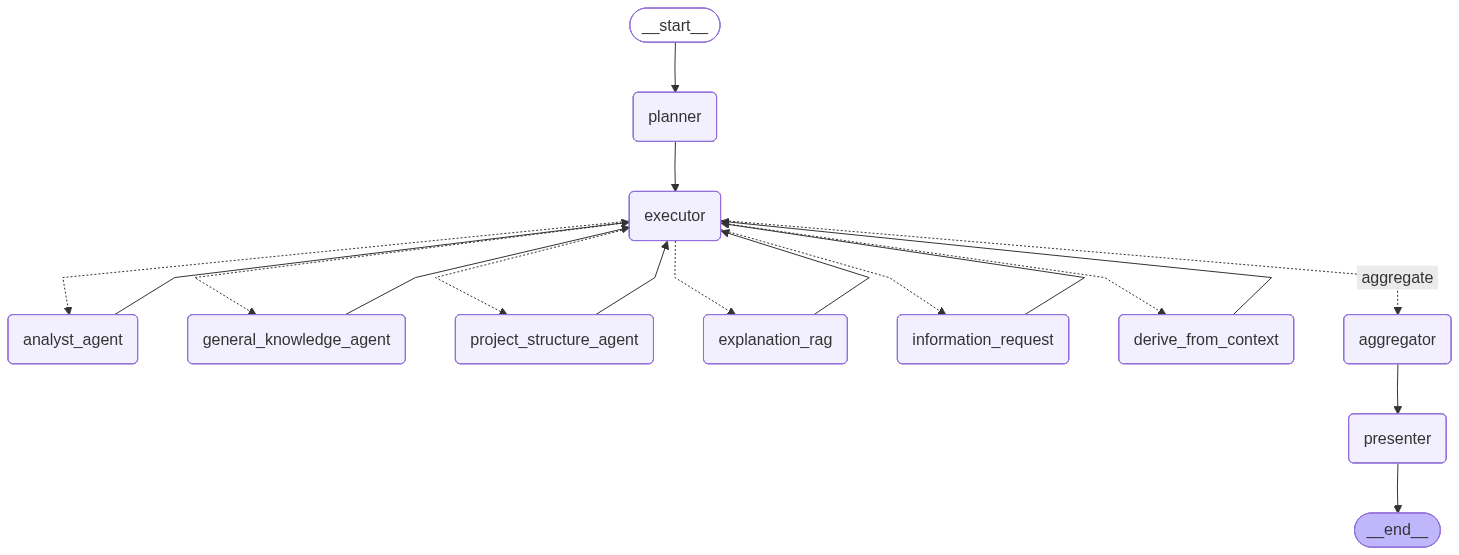

In [7]:
display( executor_app )

In [11]:
from IPython.display import Markdown, display

mermaid = executor_app.get_graph().draw_mermaid()
mermaid = mermaid.replace("graph TD", "graph LR")
mermaid = mermaid.replace("flowchart TD", "flowchart LR")

display(Markdown(f"```mermaid\n{mermaid}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph LR;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	executor(executor)
	analyst_agent(analyst_agent)
	general_knowledge_agent(general_knowledge_agent)
	project_structure_agent(project_structure_agent)
	explanation_rag(explanation_rag)
	information_request(information_request)
	derive_from_context(derive_from_context)
	aggregator(aggregator)
	presenter(presenter)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	aggregator --> presenter;
	analyst_agent --> executor;
	derive_from_context --> executor;
	executor -. &nbsp;aggregate&nbsp; .-> aggregator;
	executor -.-> analyst_agent;
	executor -.-> derive_from_context;
	executor -.-> explanation_rag;
	executor -.-> general_knowledge_agent;
	executor -.-> information_request;
	executor -.-> project_structure_agent;
	explanation_rag --> executor;
	general_knowledge_agent --> executor;
	information_request --> executor;
	planner --> executor;
	project_structure_agent --> executor;
	presenter --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

In [13]:
from IPython.display import Image, display

display(
    Image(
        executor_app.get_graph().draw_mermaid_png(
            draw_method="pyppeteer",
            mermaid_syntax="""
graph LR
    __start__ --> planner
    planner --> executor
    executor -. analyst_agent .-> analyst_agent
    executor -. general_knowledge_agent .-> general_knowledge_agent
    executor -. project_structure_agent .-> project_structure_agent
    executor -. explanation_rag .-> explanation_rag
    executor -. information_request .-> information_request
    executor -. derive_from_context .-> derive_from_context
    executor -. aggregate .-> aggregator

    analyst_agent --> executor
    general_knowledge_agent --> executor
    project_structure_agent --> executor
    explanation_rag --> executor
    information_request --> executor
    derive_from_context --> executor

    aggregator --> presenter
    presenter --> __end__
"""
        )
    )
)

TypeError: Graph.draw_mermaid_png() got an unexpected keyword argument 'mermaid_syntax'

In [ ]:


# ============================================================
# Run graph
# ============================================================

initial_state: ExecutorState = {
    "user_query": "Compare oil production by producer for 2023.",

    "plan": None,
    "task_index": 0,
    "aggregated_context": None,
    "final_answer": None,

    "tool_outputs": [],
    "general_knowledge": [],
    "facts": [],
}

result = executor_app.invoke(initial_state)

print("FINAL ANSWER:")
print(result["final_answer"])

result

In [32]:
executor_prompt = """
You are the PLANNER AGENT.

===============================================================================
Your responsibilities:
===============================================================================
1. Understand the user’s request and clarify the underlying intent.
2. Convert a user’s request into an explicit execution plan or, when appropriate, a direct answer.

====================================================
TASK TYPES
====================================================
- "analyst_agent"  → requires data access or computation on the CRMDataset dataset of a project. Useful in quantitative queries, aggregations, distances, time series
- "explanation_rag" → conceptual or theoretical explanation related to waterflooding in the context of reservoir engineering or reservoir engineering in general. Example: 'Whats GOR?' 
- "general_knowledge_agent"  → general factual knowledge (non-project-specific). Example: 'Whats the density of water?'
- "project_structure_agent" → project structure, well hierarchical distribution, well count, simulation count. Examples: '1: Whats the distribution of wells across subzones in project X?'. 2: 'How many simulations are in the project?'
- "derive_from_context" → derive a specific fact from previously produced context (LLM-only, no data access)
- "information_request" → ask the user for missing information (terminal)

====================================================
TASK ORDERING RULES
====================================================
- Tasks MUST be ordered in the exact sequence they should be executed.
- Context-producing tasks must come before tasks that consume them.
- If a task depends on prior results, you MUST either:
  - use "derive_from_context", or
  - make the dependency explicit in the instruction.
- General knowledge or explanations come before data queries.
- Project structure tasks come before analytical computations.
- Analytical tasks (analyst_agent) come last.
- Do NOT merge tasks. Use multiple tasks when steps are sequential.
- Do NOT assume implicit dependencies.
"""



In [33]:
llm = azure_llm_if()
print( llm )

client=<openai.resources.chat.completions.completions.Completions object at 0x000002192A6761A0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002192A6741C0> root_client=<openai.lib.azure.AzureOpenAI object at 0x000002192A676F50> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x000002192A675450> model_name='gpt-4o' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') stream_usage=True azure_endpoint='https://openai-if-test.openai.azure.com/' deployment_name='gpt-4' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [34]:
planner_agent = create_agent(
        model=llm,
        tools=[],              # NO TOOLS
        system_prompt= executor_prompt, 
        checkpointer=None,     # stateless
        response_format=Plan
    )

In [35]:
query = "whats the density of water?"
result = planner_agent.invoke({"messages": [{"role": "user", "content": query}]})
    

In [36]:
print(result['structured_response'].model_dump_json(indent=2))


{
  "agent": "planner",
  "user_intent": "Provide the density of water.",
  "tasks": [
    {
      "tool": "general_knowledge_agent",
      "instruction": "What is the density of water at standard conditions?"
    }
  ]
}


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

from typing import Literal, TypedDict
from pydantic import BaseModel, Field


class Task(BaseModel):
    tool: Literal[
        "analyst_agent",
        "explanation_rag",
        "general_knowledge_agent",
        "project_structure_agent",
        "information_request",
        "derive_from_context",
    ] = Field(
        description="Which agent/tool must execute this task."
    )

    instruction: str = Field(
        description=(
            "Exact instruction string to pass verbatim to the selected tool. "
            "Must be a complete, unambiguous request phrased as if directly "
            "addressing the tool."
        )
    )


class Plan(BaseModel):
    agent: Literal["planner"] = Field(
        default="planner",
        description="Fixed identifier for the planner agent."
    )

    user_intent: str = Field(
        description="One-sentence clarified user intent."
    )

    tasks: list[Task] = Field(
        description="Ordered list of tool invocations required to satisfy the intent."
    )

class ToolOutput(BaseModel):
    tool: str
    instruction: str
    output: Any

class ExecutorState(TypedDict):
    user_query: str

    general_knowledge: list[str]  
    facts: list[str]
    plan: Plan | None 
   
    task_index: int
    tool_outputs: list[ToolOutput]


In [ ]:
def planner_node(state: ExecutorState) ->dict:

    user_query =  state['user_query']
    
    messages = [
        {
            'role':'system',
            'content': executor_prompt
        },
        {
            'role':'user',
            'content': user_query
        } 
    ]

    structured_llm = llm.with_structured_output(Plan)
    plan = structured_llm.invoke(messages)
    print(plan)
    return {'plan':plan, 'task_index': 0 }
    #state['plan'] = plan # type: ignore
 
def plan_executor( state: ExecutorState )->dict: 


def analyst_node( state: ExecutorState)->dict:

def general_knowledge_node( state:ExecutorState)->dict:
    
      

In [39]:
planner_graph = StateGraph(ExecutorState)

planner_graph.add_node("planner", planner_node)

planner_graph.set_entry_point("planner")
planner_graph.add_edge("planner", END)

planner_app = planner_graph.compile()

In [ ]:
graph.add_conditional_edges(
    "executor",
    route_next_task,
    {
        "analyst_agent": "analyst_agent",
        "general_knowledge_agent": "general_knowledge_agent",
        "project_structure_agent": "project_structure_agent",
        "explanation_rag": "explanation_rag",
        "derive_from_context": "derive_from_context",
        "information_request": "information_request",
        "done": END,
    },
)

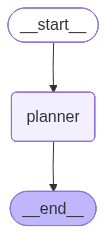

In [45]:
planner_app

In [42]:
initial_state: ExecutorState = {
"user_query": """
Show me the average inter-well distance as a fraction of the  
the distance from Eartch to The Moon times 10000

""",
"general_knowledge": [],
"facts": [],
"plan": None,  # see note below
}

result = planner_app.invoke(initial_state)

result["plan"]

agent='planner' user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.' tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')]


Plan(agent='planner', user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.', tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')])

In [44]:
result

{'user_query': '\nShow me the average inter-well distance as a fraction of the  \nthe distance from Eartch to The Moon times 10000\n\n',
 'general_knowledge': [],
 'facts': [],
 'plan': Plan(agent='planner', user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.', tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')])}